# 실전 프로젝트 1: 금융 분석기 프로토타입 (LangGraph 기반)

이 노트북은 본격적인 파이썬 모듈화(Phase 2)에 앞서, **LangGraph의 핵심 로직(라우팅, 분석, 자가 반성)**이 정상 작동하는지 테스트하는 프로토타입입니다.

## 🎯 시나리오 설계
1. **Router**: 사용자의 질문이 "텍스트 문서(보고서)" 관련인지 "이미지(차트)" 관련인지 분류합니다.
2. **RAG / Vision Node**: 문서를 검색하거나 차트를 읽어 맥락(Context)을 확보합니다. (이 노트북에서는 임시 모의 데이터로 테스트합니다.)
3. **Analyzer**: 확보된 맥락을 바탕으로 펀드매니저 수준의 재무 분석을 수행합니다.
4. **Reflection (Critic)**: 작성된 분석글을 평가합니다. 숫자가 부족하거나 논리가 약하면(에러) 피드백을 주고 다시 Analyzer로 돌려보냅니다.

In [1]:
import os
from typing import TypedDict, List
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, END

load_dotenv()
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## 1. Graph State 정의
노드 간에 주고받을 데이터(상태)를 정의합니다.

In [2]:
class AgentState(TypedDict):
    question: str
    route: str           # "pdf" or "image"
    context: str         # RAG나 Vision에서 얻은 팩트 데이터
    analysis: str        # 초안 분석 내용
    feedback: str        # 비평가의 피드백
    revision_count: int  # 무한 루프 방지용 카운터

## 2. 노드(Nodes) 함수 구현

In [3]:
# 1. 라우터 노드
def router_node(state: AgentState):
    print("\n[1. Router] 질문 유형을 판단합니다...")
    prompt = ChatPromptTemplate.from_template(
        "다음 질문이 '차트/그래프/이미지'를 분석해야 하는 질문이면 'image', '재무제표/보고서/텍스트'를 검색해야 하는 질문이면 'pdf'라고만 대답해.\n"
        "질문: {question}"
    )
    result = (prompt | llm).invoke({"question": state["question"]}).content.strip().lower()
    route = "image" if "image" in result else "pdf"
    print(f"  -> 라우팅 결과: {route}")
    return {"route": route}

# 2-A. RAG 모의 노드 (Phase 2에서 실제 PDF 파싱으로 대체)
def rag_node(state: AgentState):
    print("[2-A. RAG] PDF 보고서를 검색합니다...")
    return {"context": "[PDF 검색 결과] 애플의 2026년 2분기 매출은 전년 동기 대비 15% 증가한 1,200억 달러를 기록했습니다."}

# 2-B. Vision 모의 노드 (Phase 2에서 실제 이미지 분석으로 대체)
def vision_node(state: AgentState):
    print("[2-B. Vision] 차트 이미지를 분석합니다...")
    return {"context": "[Vision 분석 결과] 첨부된 주가 차트는 3일 연속 하락세(음봉)를 보이며 150달러 지지선을 이탈했습니다."}

# 3. Analyzer(분석가) 노드
def analyzer_node(state: AgentState):
    print(f"\n[3. Analyzer] 맥락을 바탕으로 분석 초안을 작성합니다. (시도 횟수: {state.get('revision_count', 0) + 1})")
    feedback_msg = f"\n\n이전 피드백: {state['feedback']}" if state.get('feedback') else ""
    prompt = ChatPromptTemplate.from_template(
        "당신은 월스트리트 수석 펀드매니저입니다. 다음 맥락을 바탕으로 사용자의 질문에 대한 분석 리포트를 3문장으로 작성하세요."
        "{feedback_msg}\n\n맥락: {context}\n질문: {question}"
    )
    analysis = (prompt | llm).invoke({
        "context": state["context"], 
        "question": state["question"], 
        "feedback_msg": feedback_msg
    }).content
    
    new_count = state.get('revision_count', 0) + 1
    return {"analysis": analysis, "revision_count": new_count}

# 4. Reflection(비평가) 노드
def reflection_node(state: AgentState):
    print("\n[4. Reflection] 작성된 초안의 퀄리티를 검증합니다...")
    prompt = ChatPromptTemplate.from_template(
        "당신은 깐깐한 편집장입니다. 다음 분석 리포트에 '구체적인 숫자나 수치'가 포함되어 있는지 확인하세요.\n"
        "숫자가 포함되어 완벽하다면 'PASS'라고만 응답하고, 부족하다면 어떤 점을 보완해야 할지 1문장으로 피드백하세요.\n\n"
        "리포트: {analysis}"
    )
    feedback = (prompt | llm).invoke({"analysis": state["analysis"]}).content
    print(f"  -> 검증 결과: {feedback}")
    return {"feedback": feedback}

## 3. 조건부 엣지(Edges) 함수

In [4]:
def route_after_router(state: AgentState):
    return "rag" if state["route"] == "pdf" else "vision"

def route_after_reflection(state: AgentState):
    if "PASS" in state["feedback"] or state["revision_count"] >= 3:
        return "end"
    else:
        return "retry"

## 4. LangGraph 조립 및 실행

In [ ]:
# 그래프 인스턴스 생성
workflow = StateGraph(AgentState)

# 노드 추가
workflow.add_node("router", router_node)
workflow.add_node("rag", rag_node)
workflow.add_node("vision", vision_node)
workflow.add_node("analyzer", analyzer_node)
workflow.add_node("reflection", reflection_node)

# 엣지 연결 (흐름도)
workflow.set_entry_point("router")
workflow.add_conditional_edges(
    "router",
    route_after_router,
    {"rag": "rag", "vision": "vision"}
)
workflow.add_edge("rag", "analyzer")
workflow.add_edge("vision", "analyzer")
workflow.add_edge("analyzer", "reflection")

# 순환 루프 (Reflection 결과에 따라 다시 돌아갈지 종료할지)
workflow.add_conditional_edges(
    "reflection",
    route_after_reflection,
    {"retry": "analyzer", "end": END}
)

# 그래프 컴파일
app = workflow.compile()

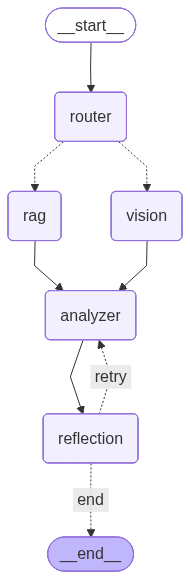

In [6]:
app

## 5. 테스트 실행
첫 번째 질문: 보고서 관련 (RAG 라우팅 확인)
두 번째 질문: 차트 이미지 관련 (Vision 라우팅 확인)

In [7]:
print("===========================================================")
print("🧪 테스트 1: 문서(PDF) 분석 질문")
print("===========================================================")
inputs = {"question": "애플의 2026년 2분기 매출 보고서를 보고 요약해줘."}
result1 = app.invoke(inputs)

print("\n\n===========================================================")
print("🧪 테스트 2: 이미지(차트) 분석 질문")
print("===========================================================")
inputs = {"question": "이 첨부된 주가 차트 이미지를 보고 향후 매매 전략을 세워줘."}
result2 = app.invoke(inputs)

print("\n\n🎉 [최종 결과물 확인]")
print("[테스트 1 결과]:", result1['analysis'])
print("[테스트 2 결과]:", result2['analysis'])

🧪 테스트 1: 문서(PDF) 분석 질문

[1. Router] 질문 유형을 판단합니다...
  -> 라우팅 결과: pdf
[2-A. RAG] PDF 보고서를 검색합니다...

[3. Analyzer] 맥락을 바탕으로 분석 초안을 작성합니다. (시도 횟수: 1)

[4. Reflection] 작성된 초안의 퀄리티를 검증합니다...
  -> 검증 결과: PASS


🧪 테스트 2: 이미지(차트) 분석 질문

[1. Router] 질문 유형을 판단합니다...
  -> 라우팅 결과: image
[2-B. Vision] 차트 이미지를 분석합니다...

[3. Analyzer] 맥락을 바탕으로 분석 초안을 작성합니다. (시도 횟수: 1)

[4. Reflection] 작성된 초안의 퀄리티를 검증합니다...
  -> 검증 결과: 부족하다면 구체적인 숫자나 수치를 추가하여 하락폭이나 예상 손실 규모를 명시해야 합니다.

[3. Analyzer] 맥락을 바탕으로 분석 초안을 작성합니다. (시도 횟수: 2)

[4. Reflection] 작성된 초안의 퀄리티를 검증합니다...
  -> 검증 결과: PASS


🎉 [최종 결과물 확인]
[테스트 1 결과]: 애플은 2026년 2분기에 전년 동기 대비 15% 증가한 1,200억 달러의 매출을 기록하며 강력한 성장세를 이어갔습니다. 이러한 성장은 주로 신제품 출시와 서비스 부문 확장에 기인하며, 소비자 수요가 여전히 높은 것으로 나타났습니다. 앞으로도 애플의 지속적인 혁신과 시장 점유율 확대가 매출 성장에 긍정적인 영향을 미칠 것으로 예상됩니다.
[테스트 2 결과]: 첨부된 주가 차트는 3일 연속 하락세를 보이며 150달러 지지선을 이탈한 상황으로, 이는 단기적으로 추가 하락 가능성을 시사합니다. 현재 주가는 145달러로, 140달러의 다음 지지선까지 하락할 경우 약 3.45%의 손실이 예상됩니다. 따라서, 매매 전략으로는 140달러에서 매수 기회를 모색하거나, 손실을 최소화하기 위해 145달러에서 손절매를 고려하는 것이 바람직합니